# TimeSeries analysis and forecasting with the new `mnplib` API

This notebook showcases the redesigned `TimeSeries` class.

The new class treats forecasting as **minimum-nescience model selection over lagged representations**:

```python
ordered series -> lagged supervised representation
candidate forecaster -> selected subset, predictions, model_string
metrics -> deficiency, surplus, inaccuracy, surfeit
select candidate with minimum nescience
```

The implementation follows the current explicit-artifact API. The metrics do not inspect fitted model objects directly. Instead, each candidate is evaluated through:

- `subset`: selected lagged features;
- `predictions`: one-step predictions on the lagged representation;
- `model_string`: a canonical description of the forecasting rule.

This notebook covers:

- target auto-lag analysis;
- exogenous cross-lag analysis;
- candidate comparison;
- selected model explanation;
- canonical model strings;
- recursive forecasting;
- model-family restrictions;
- exogenous-variable forecasting;
- rolling nescience for regime-change detection.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nescience.timeseries import TimeSeries

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (11, 4)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## 2. Helper functions

In [2]:
def plot_series(y, title, *, ylabel="Value"):
    """Plot a one-dimensional series."""
    pd.Series(y).plot(figsize=(11, 4))
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_candidate_nescience(results, title):
    """Plot scalar nescience for fitted time-series candidates."""
    results.set_index("model_name")["nescience"].plot(kind="bar", figsize=(12, 4))
    plt.title(title)
    plt.ylabel("Nescience")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_candidate_components(results, title):
    """Plot the four nescience components for fitted candidates."""
    component_cols = ["deficiency", "surplus", "inaccuracy", "surfeit"]
    results.set_index("model_name")[component_cols].plot(kind="bar", figsize=(12, 5))
    plt.title(title)
    plt.ylabel("Component value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_forecast(y, forecast, title):
    """Plot observed history and recursive forecasts."""
    history = pd.Series(y)
    future_index = np.arange(len(y), len(y) + len(forecast))
    plt.figure(figsize=(11, 4))
    plt.plot(history.index, history.values, label="Observed")
    plt.plot(future_index, forecast, marker="o", label="Forecast")
    plt.axvline(len(y) - 1, linestyle="--")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_components(model):
    """Print selected model components."""
    for name, value in model.components().items():
        print(f"{name:>10}: {value:.6f}")


def compact_results(results):
    """Return the most useful result-table columns."""
    columns = [
        "model_name",
        "model_family",
        "nescience",
        "estimator_score",
        "deficiency",
        "surplus",
        "miscoding",
        "inaccuracy",
        "surfeit",
        "n_features_in_use",
        "description_length",
        "selected_feature_names",
    ]
    return results[columns]

## 3. Example 1: a synthetic autoregressive series

We start with a simple series where the current value depends mainly on recent past target values. This is the canonical case for an autoregressive candidate.


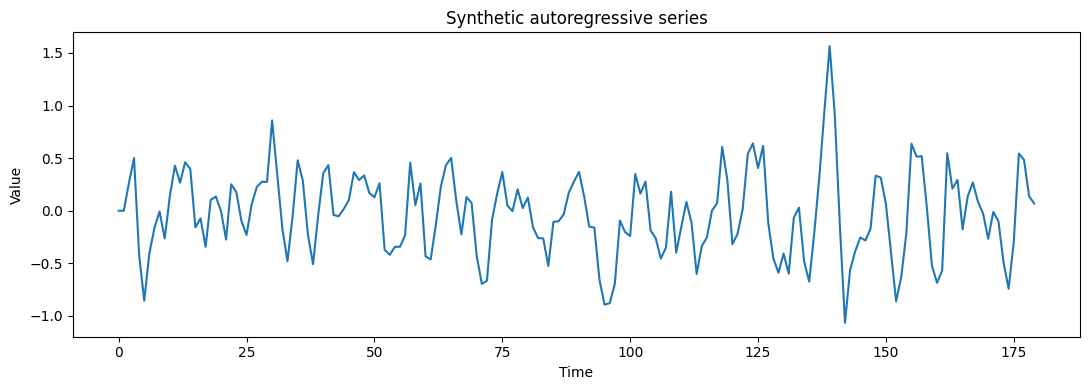

In [3]:
n = 180
noise = rng.normal(0.0, 0.35, size=n)
y = np.zeros(n)

for t in range(2, n):
    y[t] = 0.65 * y[t - 1] - 0.25 * y[t - 2] + noise[t]

plot_series(y, "Synthetic autoregressive series")

## 4. Fit the redesigned `TimeSeries` estimator

The estimator builds the lagged representation internally, evaluates the configured candidate families, and selects the candidate with minimum nescience.


In [4]:
ts = TimeSeries(
    window_size=8,
    models=("autoregressive", "moving_average", "exponential_smoothing"),
    moving_average_windows=(1, 2, 3, 5, 8),
    smoothing_alphas=(0.2, 0.5, 0.8),
    n_bins="auto",
    min_improvement=0.0,
    description_precision=4,
    random_state=RANDOM_SEED,
    verbose=1,
)

ts.fit(y)

exponential_smoothing_w5_a0.8: nescience=0.702943, estimator_score=0.121546
exponential_smoothing_w3_a0.8: nescience=0.703219, estimator_score=0.117576
exponential_smoothing_w8_a0.8: nescience=0.709271, estimator_score=0.121826
exponential_smoothing_w2_a0.8: nescience=0.713380, estimator_score=0.122777
autoregressive: nescience=0.713460, estimator_score=0.346521
moving_average_1: nescience=0.714275, estimator_score=0.177173
exponential_smoothing_w1_a0.5: nescience=0.714372, estimator_score=0.177173
exponential_smoothing_w1_a0.8: nescience=0.714372, estimator_score=0.177173
exponential_smoothing_w1_a0.2: nescience=0.714746, estimator_score=0.177173
exponential_smoothing_w3_a0.5: nescience=0.715073, estimator_score=-0.040099
exponential_smoothing_w5_a0.5: nescience=0.716007, estimator_score=-0.019257
exponential_smoothing_w3_a0.2: nescience=0.719033, estimator_score=-0.227925
exponential_smoothing_w8_a0.5: nescience=0.719535, estimator_score=-0.000282
exponential_smoothing_w5_a0.2: nesci

,y_type,'numeric'
,X_type,'numeric'
,window_size,8
,max_lag,None
,models,"('autoregressive', ...)"
,moving_average_windows,"(1, ...)"
,smoothing_alphas,"(0.2, ...)"
,aggregation,'euclidean'
,weights,None
,n_bins,'auto'
,min_improvement,0.0


## 5. Selected model and main diagnostics

In [5]:
print("Selected model:", ts.model_name_)
print("Model family:", ts.best_result_.model_family)
print("Window size:", ts.window_size_)
print("Selected feature names:", ts.selected_feature_names_)
print("Native estimator score:", ts.score(y))
print("Nescience:", ts.nescience_score())

print("\nComponents:")
print_components(ts)

Selected model: exponential_smoothing_w5_a0.8
Model family: exponential_smoothing
Window size: 8
Selected feature names: ['y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_4', 'y_lag_5']
Native estimator score: 0.1215464470642802
Nescience: 0.7029432601011856

Components:
deficiency: 0.618621
   surplus: 0.856755
inaccuracy: 0.808198
   surfeit: 0.454545


## 6. Candidate comparison table

The table is sorted by ascending nescience, so the selected candidate appears first.


In [6]:
results = ts.results_dataframe()
compact_results(results)

,model_name,model_family,nescience,estimator_score,deficiency,surplus,miscoding,inaccuracy,surfeit,n_features_in_use,description_length,selected_feature_names
0,exponential_smoothing_w5_a0.8,exponential_smoothing,0.702943,0.121546,0.618621,0.856755,0.856755,0.808198,0.454545,5,429,"(y_lag_1, y_lag_2, y_lag_3, y_lag_4, y_lag_5)"
1,exponential_smoothing_w3_a0.8,exponential_smoothing,0.703219,0.117576,0.682965,0.844555,0.844555,0.807008,0.383523,3,352,"(y_lag_1, y_lag_2, y_lag_3)"
2,exponential_smoothing_w8_a0.8,exponential_smoothing,0.709271,0.121826,0.565752,0.868575,0.868575,0.808198,0.533457,8,538,"(y_lag_1, y_lag_2, y_lag_3, y_lag_4, y_lag_5, ..."
3,exponential_smoothing_w2_a0.8,exponential_smoothing,0.713380,0.122777,0.749586,0.842783,0.842783,0.808135,0.332268,2,313,"(y_lag_1, y_lag_2)"
4,autoregressive,autoregressive,0.713460,0.346521,0.808008,0.807908,0.808008,0.808008,0.278626,1,262,"(y_lag_1,)"
5,moving_average_1,moving_average,0.714275,0.177173,0.808008,0.807908,0.808008,0.808008,0.286853,1,251,"(y_lag_1,)"
6,exponential_smoothing_w1_a0.5,exponential_smoothing,0.714372,0.177173,0.808008,0.807908,0.808008,0.808008,0.287823,1,271,"(y_lag_1,)"
7,exponential_smoothing_w1_a0.8,exponential_smoothing,0.714372,0.177173,0.808008,0.807908,0.808008,0.808008,0.287823,1,271,"(y_lag_1,)"
8,exponential_smoothing_w1_a0.2,exponential_smoothing,0.714746,0.177173,0.808008,0.807908,0.808008,0.808008,0.291513,1,271,"(y_lag_1,)"
9,exponential_smoothing_w3_a0.5,exponential_smoothing,0.715073,-0.040099,0.682965,0.844555,0.844555,0.850198,0.377841,3,352,"(y_lag_1, y_lag_2, y_lag_3)"


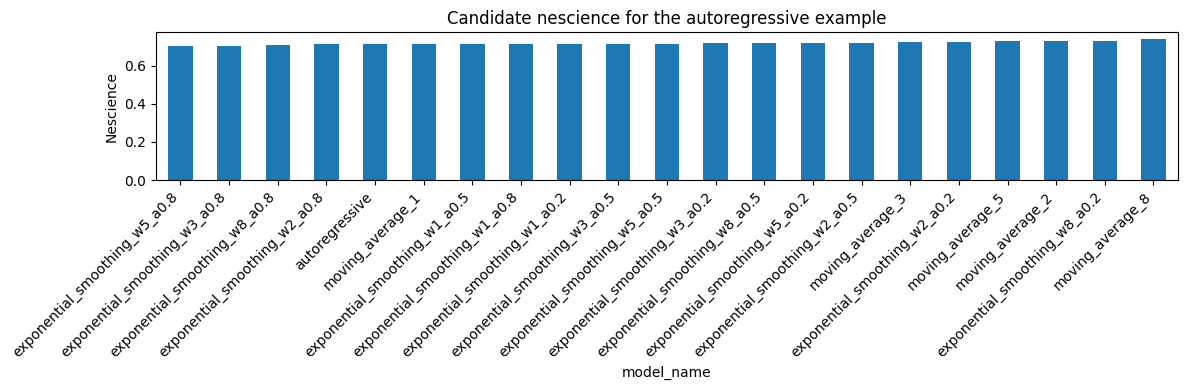

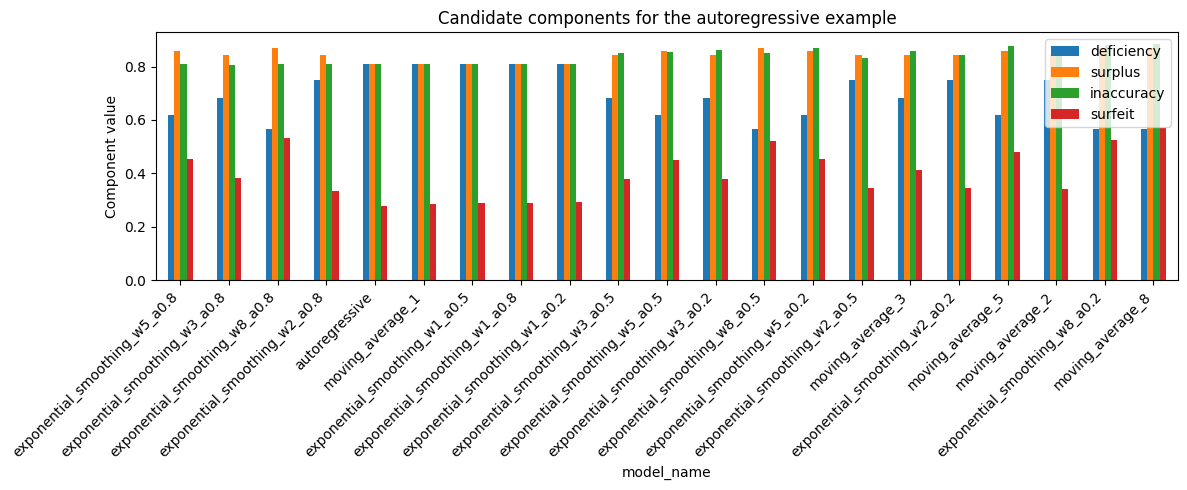

In [7]:
plot_candidate_nescience(results, "Candidate nescience for the autoregressive example")
plot_candidate_components(results, "Candidate components for the autoregressive example")

## 7. Auto-miscoding: target lag diagnostics

`auto_lag_analysis()` evaluates how informative each lag of the target is with respect to the current target value. Lower miscoding is better.


In [8]:
auto_lags = ts.auto_lag_analysis(max_lag=12)
auto_lags

,lag,feature_name,deficiency,surplus,miscoding
0,1,y_lag_1,0.824484,0.824371,0.824484
1,2,y_lag_2,0.876807,0.876644,0.876807
2,3,y_lag_3,0.854341,0.853781,0.854341
3,4,y_lag_4,0.874732,0.874217,0.874732
4,5,y_lag_5,0.875770,0.875453,0.875770
5,6,y_lag_6,0.891252,0.891133,0.891252
6,7,y_lag_7,0.893061,0.892771,0.893061
7,8,y_lag_8,0.882801,0.882500,0.882801
8,9,y_lag_9,0.883067,0.882784,0.883067
9,10,y_lag_10,0.887526,0.887252,0.887526


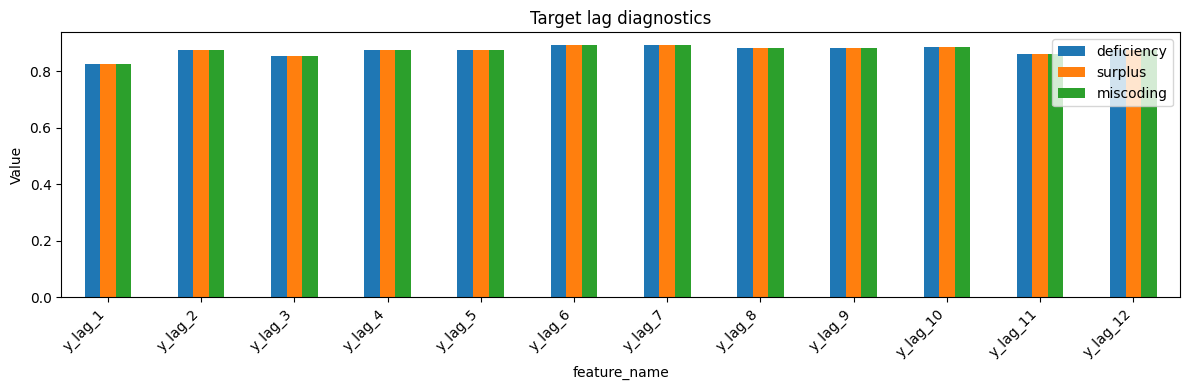

In [9]:
auto_lags.set_index("feature_name")[["deficiency", "surplus", "miscoding"]].plot(
    kind="bar",
    figsize=(12, 4),
)
plt.title("Target lag diagnostics")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Canonical model string

The selected forecasting rule is represented by a canonical string. This is the string consumed by the `Surfeit` metric.


In [10]:
model_string = ts.model_string()

print(model_string[:2500])
print("\nDescription length in bytes:", len(model_string.encode("utf-8")))

SCHEMA canonical_nescience_time_series_model_v1
MODEL exponential_smoothing
TASK forecasting
NAME exponential_smoothing_w5_a0.8
INPUTS y_lag_1, y_lag_2, y_lag_3, y_lag_4, y_lag_5
PARAMETERS
    n_features = 5
    learned_coefficients = false
RULE
    y_hat = 0.0
    y_hat += 0.8003 * y_lag_1
    y_hat += 0.1601 * y_lag_2
    y_hat += 0.032 * y_lag_3
    y_hat += 0.0064 * y_lag_4
    y_hat += 0.0013 * y_lag_5
    return y_hat


Description length in bytes: 429


## 9. Structured explanation

`explain()` gives a compact interpretation of the selected model and its dominant source of nescience.


In [11]:
explanation = ts.explain()

print("Profile:", explanation["profile"])
print("Dominant component:", explanation["dominant_component"])
print("Recommendation:", explanation["recommendation"])

print("\nSelected lags:")
for lag in explanation["selected_lags"]:
    print(lag)

Profile: over_fed_forecaster
Dominant component: surplus
Recommendation: Dominant source of nescience: surplus (0.8568). Reduce target-irrelevant lagged information by limiting the window, removing weak exogenous variables, or increasing feature-selection strictness.

Selected lags:
{'source': 'target', 'attribute': 'y', 'lag': 1, 'feature_index': 0, 'feature_name': 'y_lag_1'}
{'source': 'target', 'attribute': 'y', 'lag': 2, 'feature_index': 1, 'feature_name': 'y_lag_2'}
{'source': 'target', 'attribute': 'y', 'lag': 3, 'feature_index': 2, 'feature_name': 'y_lag_3'}
{'source': 'target', 'attribute': 'y', 'lag': 4, 'feature_index': 3, 'feature_name': 'y_lag_4'}
{'source': 'target', 'attribute': 'y', 'lag': 5, 'feature_index': 4, 'feature_name': 'y_lag_5'}


## 10. Recursive forecasting

`forecast(steps)` produces recursive future predictions. Each forecasted value is appended to the target history and used to build the next lagged row.


In [12]:
forecast = ts.forecast(steps=20)
forecast

array([0.09514101, 0.0952419 , 0.09512702, 0.09502739, 0.09501658,
       0.09502345, 0.09502342, 0.09502336, 0.09502334, 0.09502334,
       0.09502334, 0.09502334, 0.09502334, 0.09502334, 0.09502334,
       0.09502334, 0.09502334, 0.09502334, 0.09502334, 0.09502334])

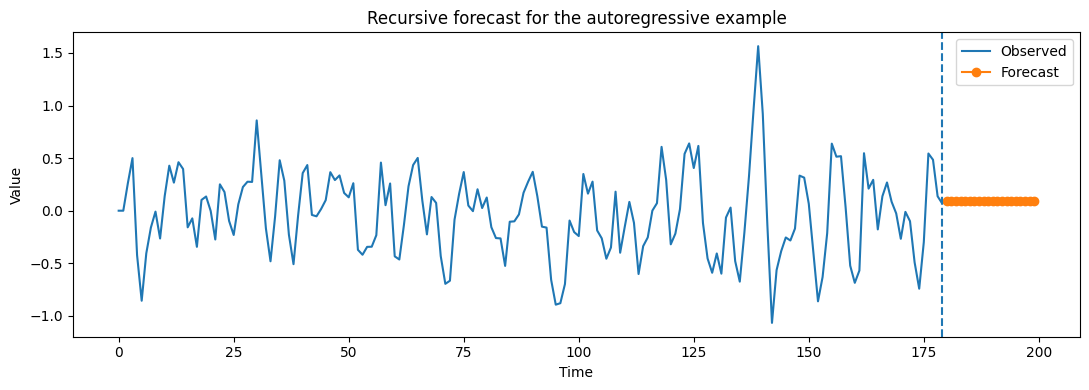

In [13]:
plot_forecast(y, forecast, "Recursive forecast for the autoregressive example")

## 11. Restricting model families

The new class lets you compare only selected forecasting families. This is useful when you want a controlled demonstration of a specific type of forecaster.


In [14]:
family_rows = []

for family in [
    ("autoregressive",),
    ("moving_average",),
    ("exponential_smoothing",),
]:
    model = TimeSeries(
        window_size=8,
        models=family,
        moving_average_windows=(1, 2, 3, 5, 8),
        smoothing_alphas=(0.2, 0.5, 0.8),
        n_bins="auto",
        description_precision=4,
        random_state=RANDOM_SEED,
    )
    model.fit(y)
    family_rows.append(
        {
            "families": ", ".join(family),
            "selected_model": model.model_name_,
            "nescience": model.nescience_score(),
            "score": model.score(y),
            **model.components(),
        }
    )

family_comparison = pd.DataFrame(family_rows)
family_comparison

,families,selected_model,nescience,score,deficiency,surplus,inaccuracy,surfeit
0,autoregressive,autoregressive,0.713460,0.346521,0.808008,0.807908,0.808008,0.278626
1,moving_average,moving_average_1,0.714275,0.177173,0.808008,0.807908,0.808008,0.286853
2,exponential_smoothing,exponential_smoothing_w5_a0.8,0.702943,0.121546,0.618621,0.856755,0.808198,0.454545


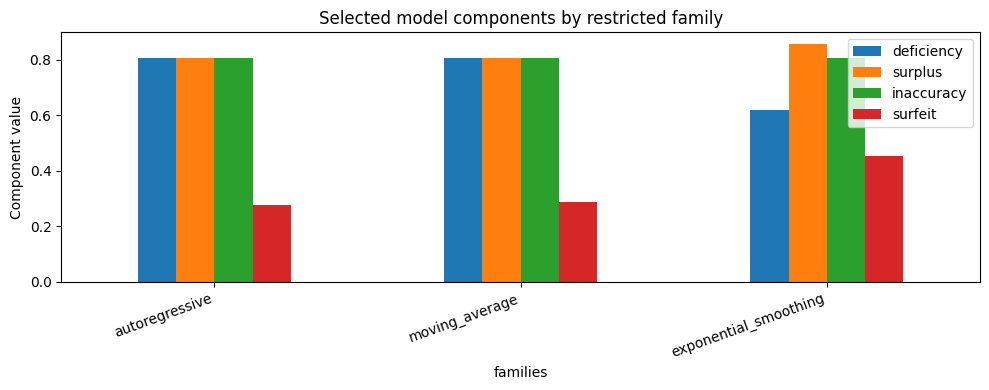

In [15]:
family_comparison.set_index("families")[["deficiency", "surplus", "inaccuracy", "surfeit"]].plot(
    kind="bar",
    figsize=(10, 4),
)
plt.title("Selected model components by restricted family")
plt.ylabel("Component value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. Example 2: forecasting with exogenous variables

Now we create a target series affected by an external temperature-like signal. The `TimeSeries` class builds lagged features for both the target and the exogenous variables.


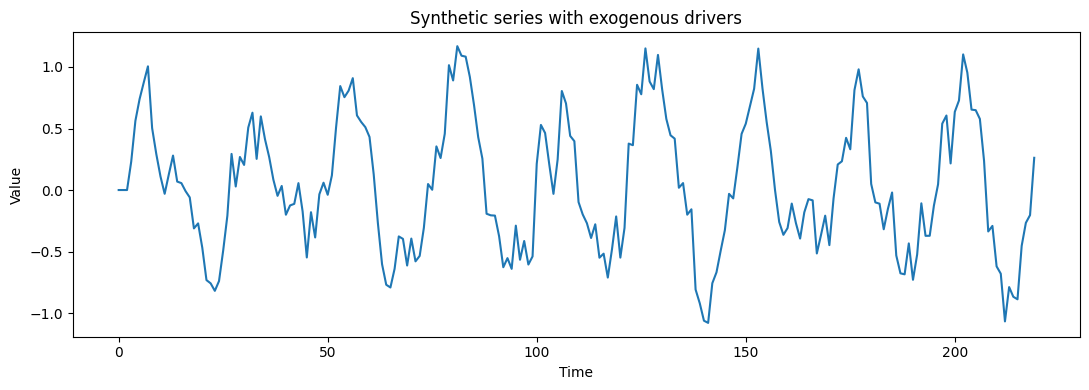

,temperature,promotion
0,0.195900,1.0
1,0.291726,1.0
2,0.438361,1.0
3,0.873050,1.0
4,0.930339,1.0


In [16]:
n = 220
time = np.arange(n)

temperature = np.sin(2 * np.pi * time / 24) + 0.15 * rng.normal(size=n)
promotion = ((time % 40) < 6).astype(float)

y_exog = np.zeros(n)
noise = 0.18 * rng.normal(size=n)

for t in range(3, n):
    y_exog[t] = (
        0.50 * y_exog[t - 1]
        + 0.35 * temperature[t - 2]
        + 0.20 * promotion[t - 1]
        + noise[t]
    )

X_exog = pd.DataFrame(
    {
        "temperature": temperature,
        "promotion": promotion,
    }
)

plot_series(y_exog, "Synthetic series with exogenous drivers")
X_exog.head()

## 13. Fit with exogenous variables

In [17]:
ts_exog = TimeSeries(
    window_size=10,
    models=("autoregressive", "moving_average", "exponential_smoothing"),
    moving_average_windows=(1, 2, 3, 5, 10),
    smoothing_alphas=(0.2, 0.5, 0.8),
    n_bins="auto",
    min_improvement=0.0,
    description_precision=4,
    random_state=RANDOM_SEED,
)

ts_exog.fit(y_exog, X=X_exog)

print("Selected model:", ts_exog.model_name_)
print("Model family:", ts_exog.best_result_.model_family)
print("Selected features:", ts_exog.selected_feature_names_)
print("Score:", ts_exog.score(y_exog, X=X_exog))
print("Nescience:", ts_exog.nescience_score())

print("\nComponents:")
print_components(ts_exog)

Selected model: moving_average_1
Model family: moving_average
Selected features: ['y_lag_1']
Score: 0.7730679933554193
Nescience: 0.5727408974665433

Components:
deficiency: 0.640272
   surplus: 0.640272
inaccuracy: 0.640272
   surfeit: 0.286853


In [18]:
exog_results = ts_exog.results_dataframe()
compact_results(exog_results)

,model_name,model_family,nescience,estimator_score,deficiency,surplus,miscoding,inaccuracy,surfeit,n_features_in_use,description_length,selected_feature_names
0,moving_average_1,moving_average,0.572741,0.773068,0.640272,0.640272,0.640272,0.640272,0.286853,1,251,"(y_lag_1,)"
1,autoregressive,autoregressive,0.572804,0.785968,0.640272,0.640272,0.640272,0.640272,0.287356,1,261,"(y_lag_1,)"
2,exponential_smoothing_w1_a0.5,exponential_smoothing,0.572863,0.773068,0.640272,0.640272,0.640272,0.640272,0.287823,1,271,"(y_lag_1,)"
3,exponential_smoothing_w1_a0.8,exponential_smoothing,0.572863,0.773068,0.640272,0.640272,0.640272,0.640272,0.287823,1,271,"(y_lag_1,)"
4,exponential_smoothing_w1_a0.2,exponential_smoothing,0.573329,0.773068,0.640272,0.640272,0.640272,0.640272,0.291513,1,271,"(y_lag_1,)"
5,exponential_smoothing_w2_a0.8,exponential_smoothing,0.591180,0.760620,0.584539,0.696007,0.696007,0.679310,0.332268,2,313,"(y_lag_1, y_lag_2)"
6,exponential_smoothing_w2_a0.5,exponential_smoothing,0.594732,0.735724,0.584539,0.696007,0.696007,0.685314,0.345048,2,313,"(y_lag_1, y_lag_2)"
7,exponential_smoothing_w2_a0.2,exponential_smoothing,0.597903,0.712210,0.584539,0.696007,0.696007,0.696261,0.345048,2,313,"(y_lag_1, y_lag_2)"
8,moving_average_2,moving_average,0.599671,0.698379,0.584539,0.696007,0.696007,0.704067,0.341463,2,287,"(y_lag_1, y_lag_2)"
9,exponential_smoothing_w3_a0.8,exponential_smoothing,0.604146,0.755025,0.559436,0.730988,0.730988,0.682325,0.383523,3,352,"(y_lag_1, y_lag_2, y_lag_3)"


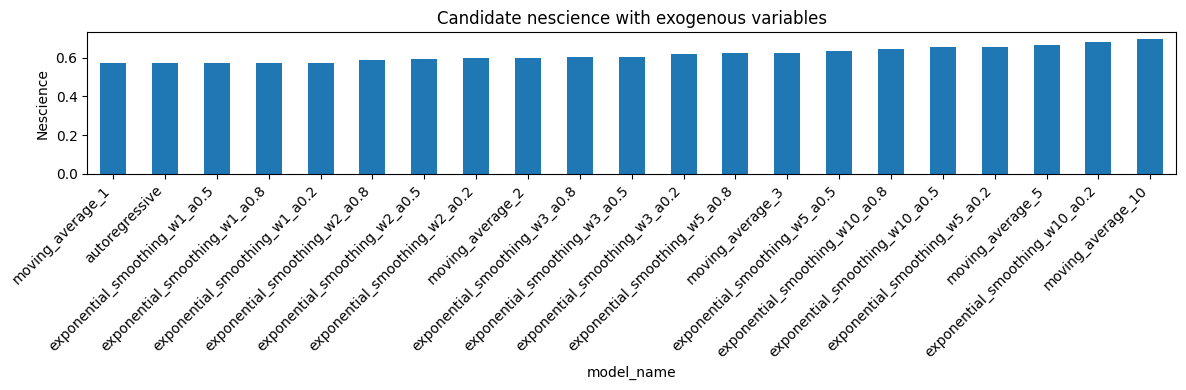

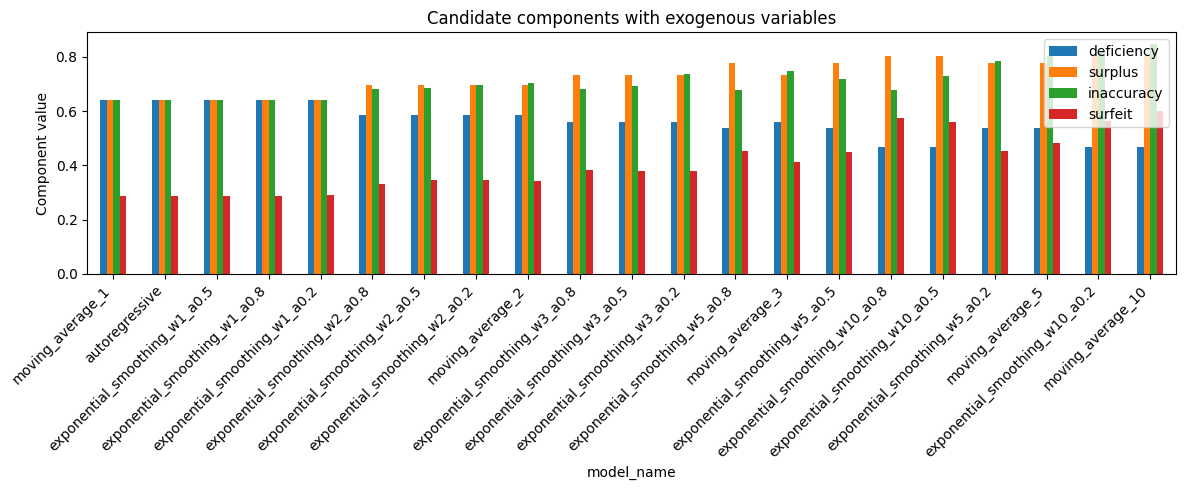

In [19]:
plot_candidate_nescience(exog_results, "Candidate nescience with exogenous variables")
plot_candidate_components(exog_results, "Candidate components with exogenous variables")

## 14. Cross-miscoding: exogenous lag diagnostics

`cross_lag_analysis(attribute)` shows how lagged values of an exogenous attribute relate to the target.


In [20]:
temperature_lags = ts_exog.cross_lag_analysis("temperature", max_lag=12)
promotion_lags = ts_exog.cross_lag_analysis("promotion", max_lag=12)

temperature_lags

,lag,feature_name,deficiency,surplus,miscoding,attribute
0,1,temperature_lag_1,0.719864,0.724234,0.724234,temperature
1,2,temperature_lag_2,0.685180,0.689806,0.689806,temperature
2,3,temperature_lag_3,0.688519,0.692933,0.692933,temperature
3,4,temperature_lag_4,0.713922,0.717622,0.717622,temperature
4,5,temperature_lag_5,0.744187,0.747488,0.747488,temperature
5,6,temperature_lag_6,0.778489,0.781396,0.781396,temperature
6,7,temperature_lag_7,0.833741,0.835972,0.835972,temperature
7,8,temperature_lag_8,0.826177,0.828783,0.828783,temperature
8,9,temperature_lag_9,0.825461,0.828021,0.828021,temperature
9,10,temperature_lag_10,0.848986,0.850890,0.850890,temperature


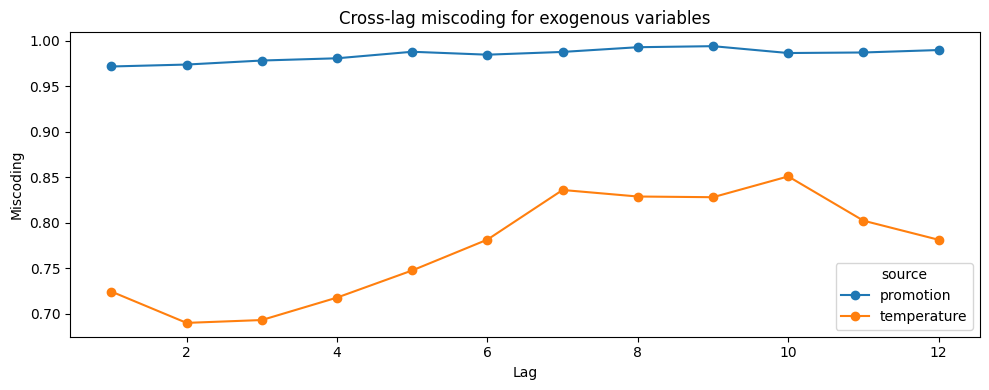

In [21]:
combined_lags = pd.concat(
    [
        temperature_lags.assign(source="temperature"),
        promotion_lags.assign(source="promotion"),
    ],
    ignore_index=True,
)

combined_lags.pivot(index="lag", columns="source", values="miscoding").plot(
    marker="o",
    figsize=(10, 4),
)
plt.title("Cross-lag miscoding for exogenous variables")
plt.ylabel("Miscoding")
plt.xlabel("Lag")
plt.tight_layout()
plt.show()

## 15. Forecasting with future exogenous values

When exogenous variables are used, future values can be supplied through `X_future`. If they are omitted, the class repeats the last observed exogenous row.


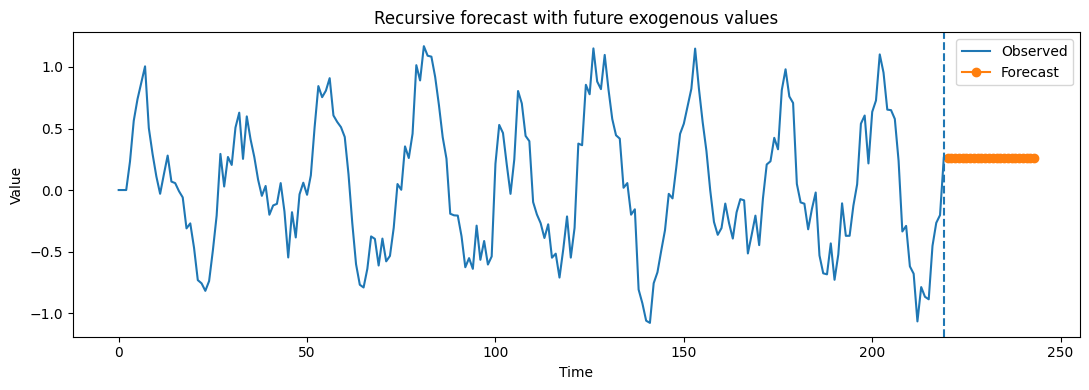

In [22]:
future_steps = 24
future_time = np.arange(n, n + future_steps)
X_future = pd.DataFrame(
    {
        "temperature": np.sin(2 * np.pi * future_time / 24),
        "promotion": ((future_time % 40) < 6).astype(float),
    }
)

forecast_exog = ts_exog.forecast(steps=future_steps, X_future=X_future)
plot_forecast(y_exog, forecast_exog, "Recursive forecast with future exogenous values")

## 16. Inspect the exogenous model string

In [23]:
print(ts_exog.model_string()[:3000])

SCHEMA canonical_nescience_time_series_model_v1
MODEL moving_average
TASK forecasting
NAME moving_average_1
INPUTS y_lag_1
PARAMETERS
    n_features = 1
    learned_coefficients = false
RULE
    y_hat = 0.0
    y_hat += 1.0 * y_lag_1
    return y_hat



## 17. Example 3: rolling nescience for regime-change detection

The old notebook included rolling nescience as a way to detect structural changes. We can reproduce the idea with the new API by fitting a small `TimeSeries` model on rolling windows and recording the selected candidate's nescience.


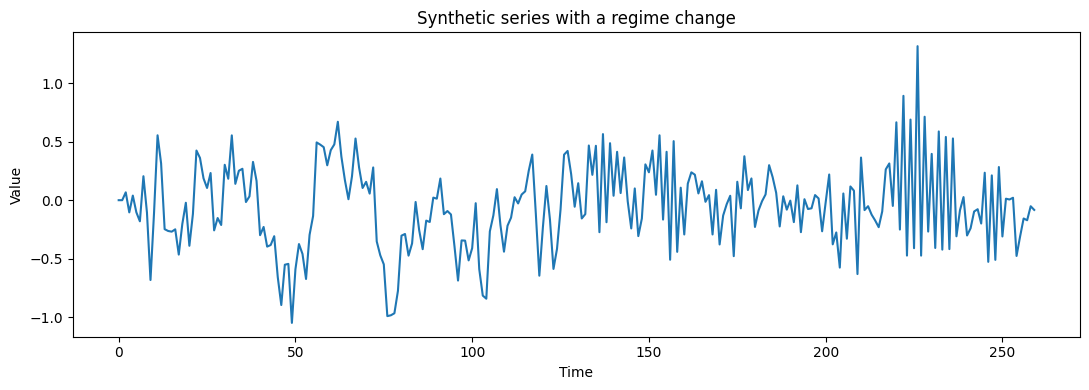

In [24]:
n = 260
regime = np.zeros(n)
regime_noise = 0.25 * rng.normal(size=n)

for t in range(2, n):
    if t < 130:
        regime[t] = 0.75 * regime[t - 1] + regime_noise[t]
    else:
        regime[t] = -0.35 * regime[t - 1] + 0.55 * regime[t - 2] + regime_noise[t]

plot_series(regime, "Synthetic series with a regime change")

In [25]:
window = 80
step = 10
rolling_rows = []

for start in range(0, len(regime) - window + 1, step):
    end = start + window
    segment = regime[start:end]

    model = TimeSeries(
        window_size=8,
        models=("autoregressive", "moving_average", "exponential_smoothing"),
        moving_average_windows=(1, 2, 3, 5, 8),
        smoothing_alphas=(0.2, 0.5, 0.8),
        n_bins=4,
        description_precision=4,
        random_state=RANDOM_SEED,
    )
    model.fit(segment)

    rolling_rows.append(
        {
            "start": start,
            "end": end,
            "center": start + window // 2,
            "selected_model": model.model_name_,
            "nescience": model.nescience_score(),
            "inaccuracy": model.components()["inaccuracy"],
            "surfeit": model.components()["surfeit"],
            "deficiency": model.components()["deficiency"],
            "surplus": model.components()["surplus"],
        }
    )

rolling = pd.DataFrame(rolling_rows)
rolling

,start,end,center,selected_model,nescience,inaccuracy,surfeit,deficiency,surplus
0,0,80,40,moving_average_1,0.715145,0.785064,0.447067,0.785064,0.783078
1,10,90,50,moving_average_1,0.682876,0.743780,0.454066,0.743780,0.743428
2,20,100,60,moving_average_1,0.659364,0.715209,0.452186,0.715209,0.715209
3,30,110,70,moving_average_1,0.635186,0.684315,0.458800,0.683210,0.684315
4,40,120,80,moving_average_1,0.645328,0.698317,0.455083,0.698317,0.695270
5,50,130,90,moving_average_1,0.667190,0.723943,0.459873,0.721735,0.723943
6,60,140,100,moving_average_1,0.733172,0.802278,0.468203,0.802278,0.802278
7,70,150,110,moving_average_1,0.761612,0.837590,0.468979,0.837590,0.834961
8,80,160,120,autoregressive,0.815506,0.900957,0.477707,0.900957,0.899194
9,90,170,130,moving_average_2,0.827662,0.924851,0.527493,0.865355,0.926097


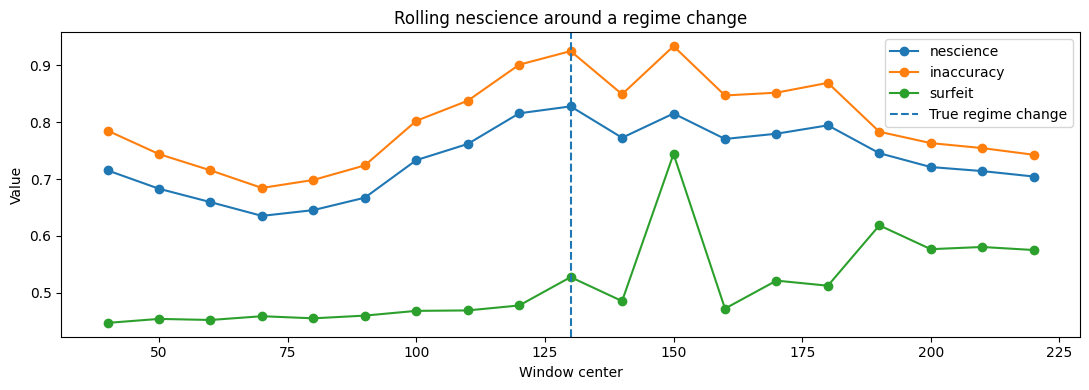

In [26]:
rolling.set_index("center")[["nescience", "inaccuracy", "surfeit"]].plot(
    marker="o",
    figsize=(11, 4),
)
plt.axvline(130, linestyle="--", label="True regime change")
plt.title("Rolling nescience around a regime change")
plt.xlabel("Window center")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## 18. Summary

The redesigned `TimeSeries` class exposes a compact and consistent API:

```python
ts = TimeSeries(...)
ts.fit(y, X=None)

ts.results_dataframe()
ts.nescience_score()
ts.components()
ts.explain()
ts.model_string()
ts.forecast(steps, X_future=None)
ts.auto_lag_analysis()
ts.cross_lag_analysis(attribute)
ts.lag_analysis()
```

The key conceptual change is that forecasting candidates are evaluated through explicit artifacts:

```python
subset, predictions, model_string
```

This keeps the metric layer independent from the forecasting implementation and makes the time-series class easier to maintain.
